In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
import operator

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

# Cấu hình mặc định
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


c:\Users\Admin\anaconda3\envs\lstm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\student_habits_performance.csv")

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
df = df.drop(columns=['student_id'])


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       909 non-null    object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

In [6]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [7]:
most_common = df['parental_education_level'].mode()[0]
df['parental_education_level'].fillna(most_common, inplace=True)


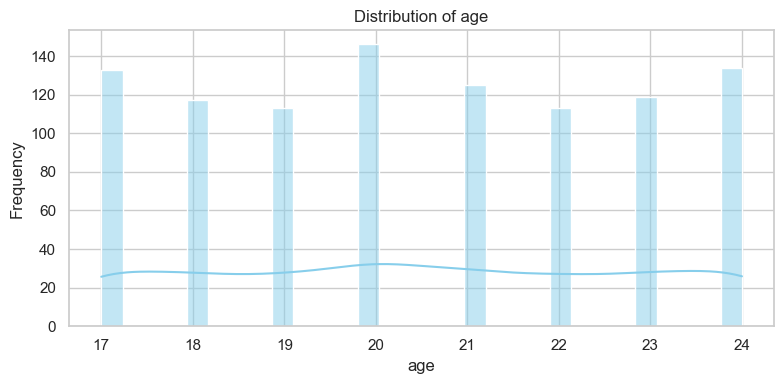

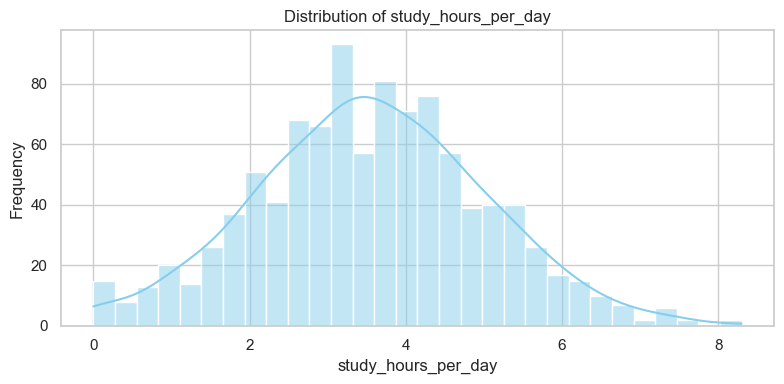

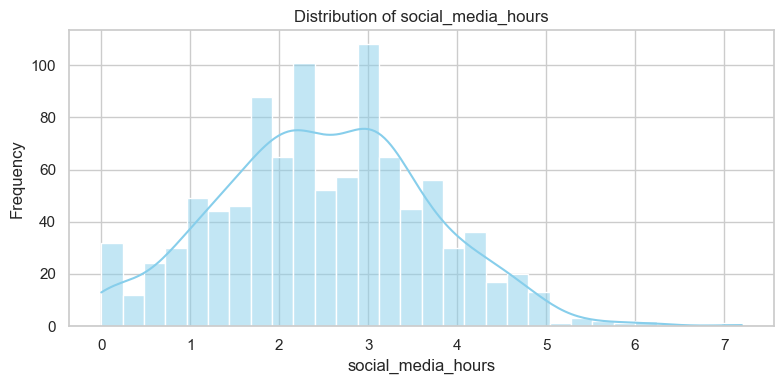

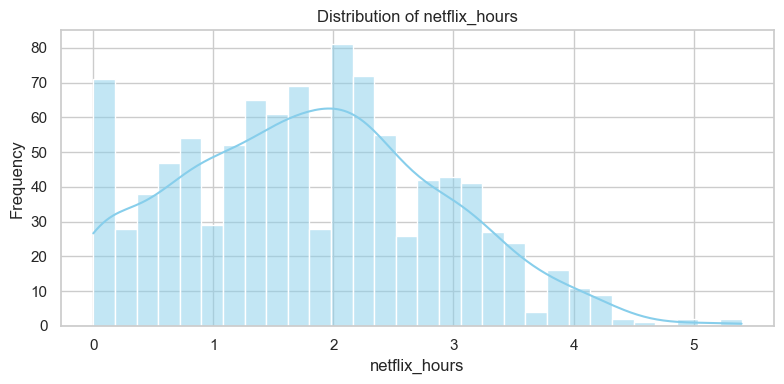

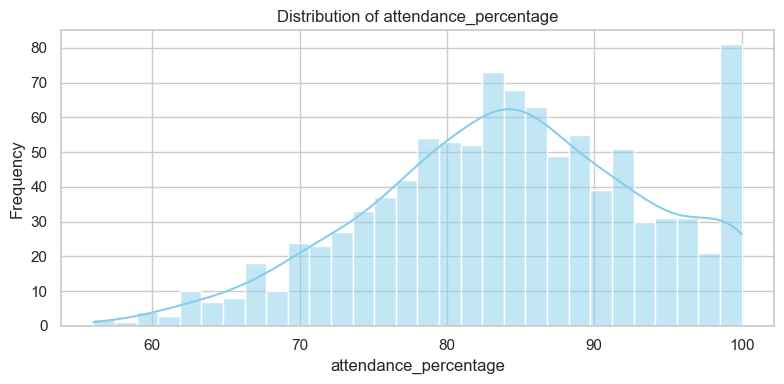

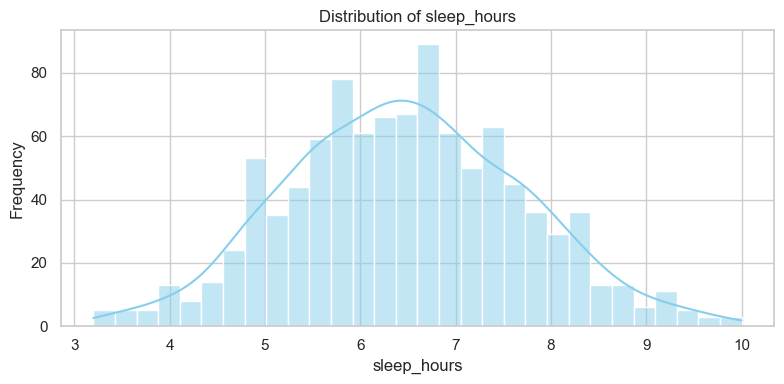

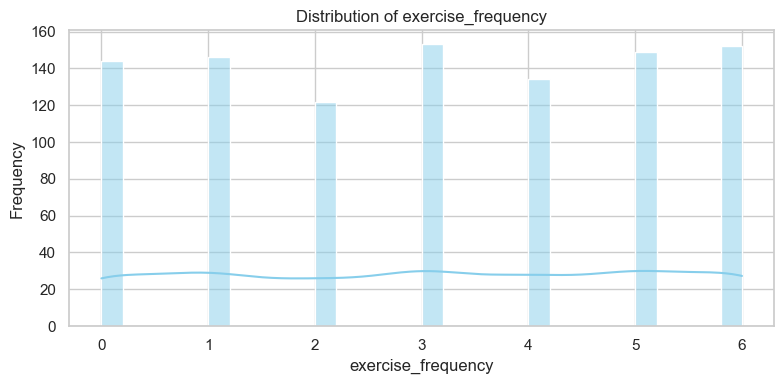

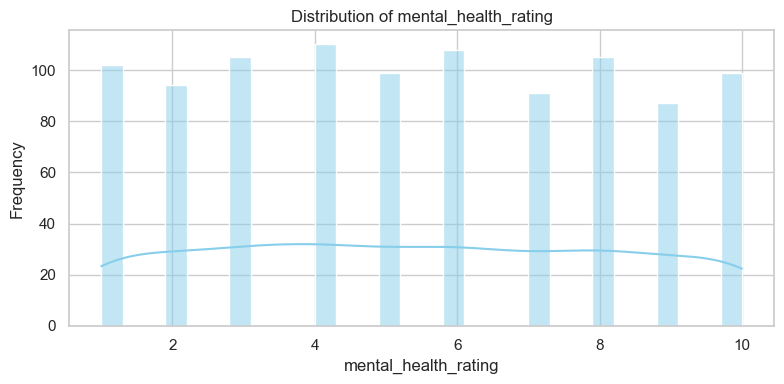

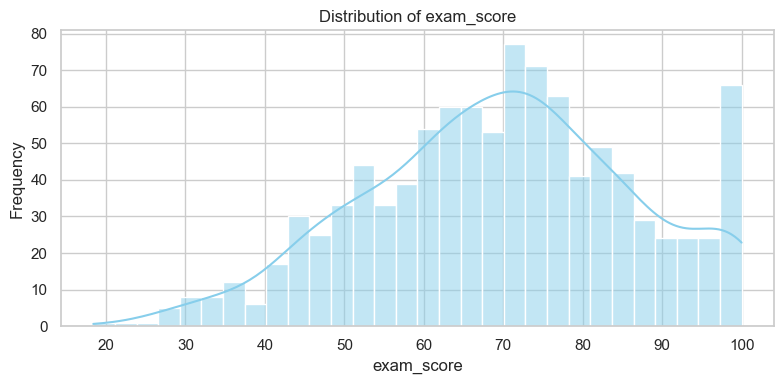

In [8]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


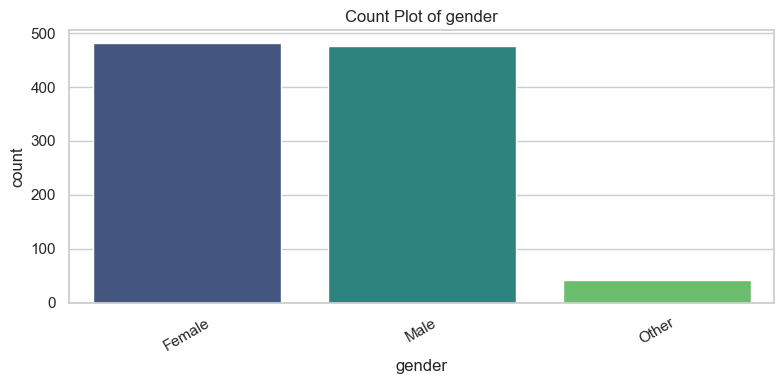

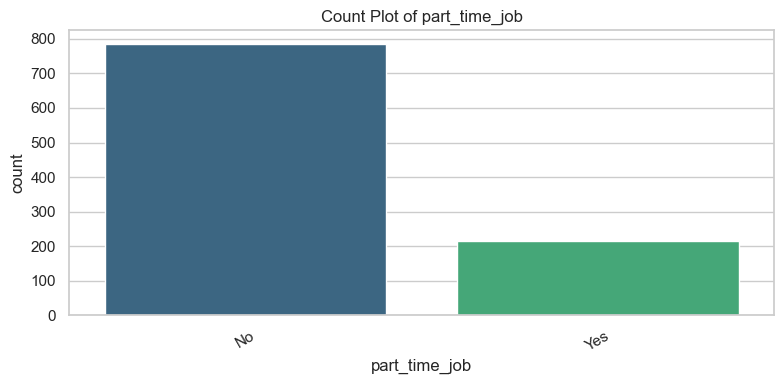

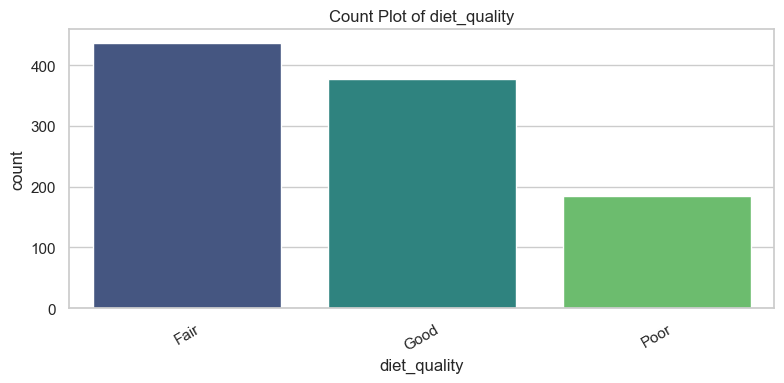

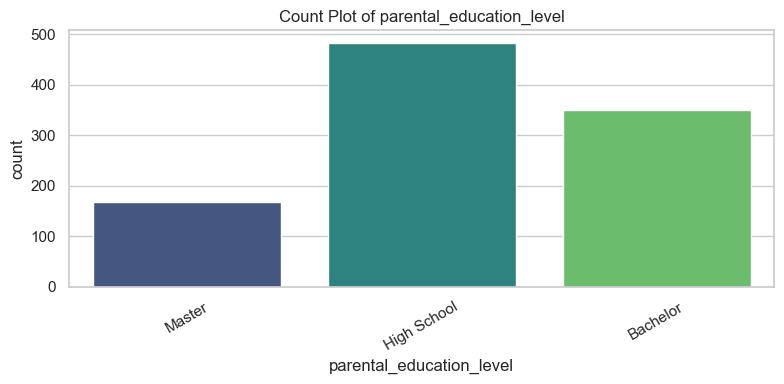

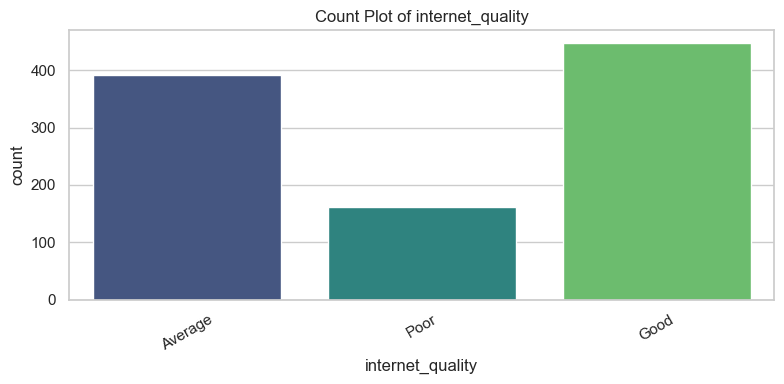

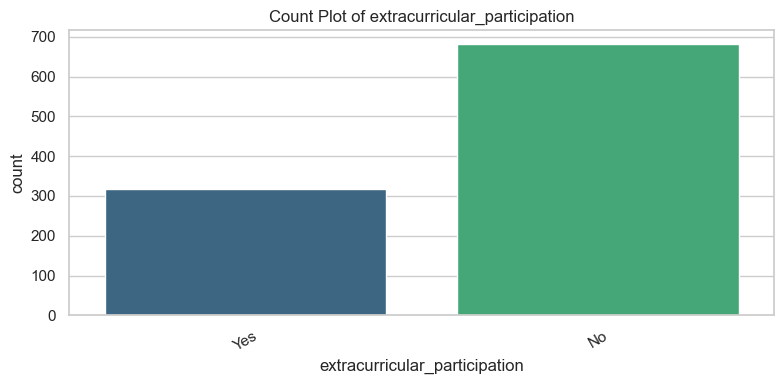

In [9]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


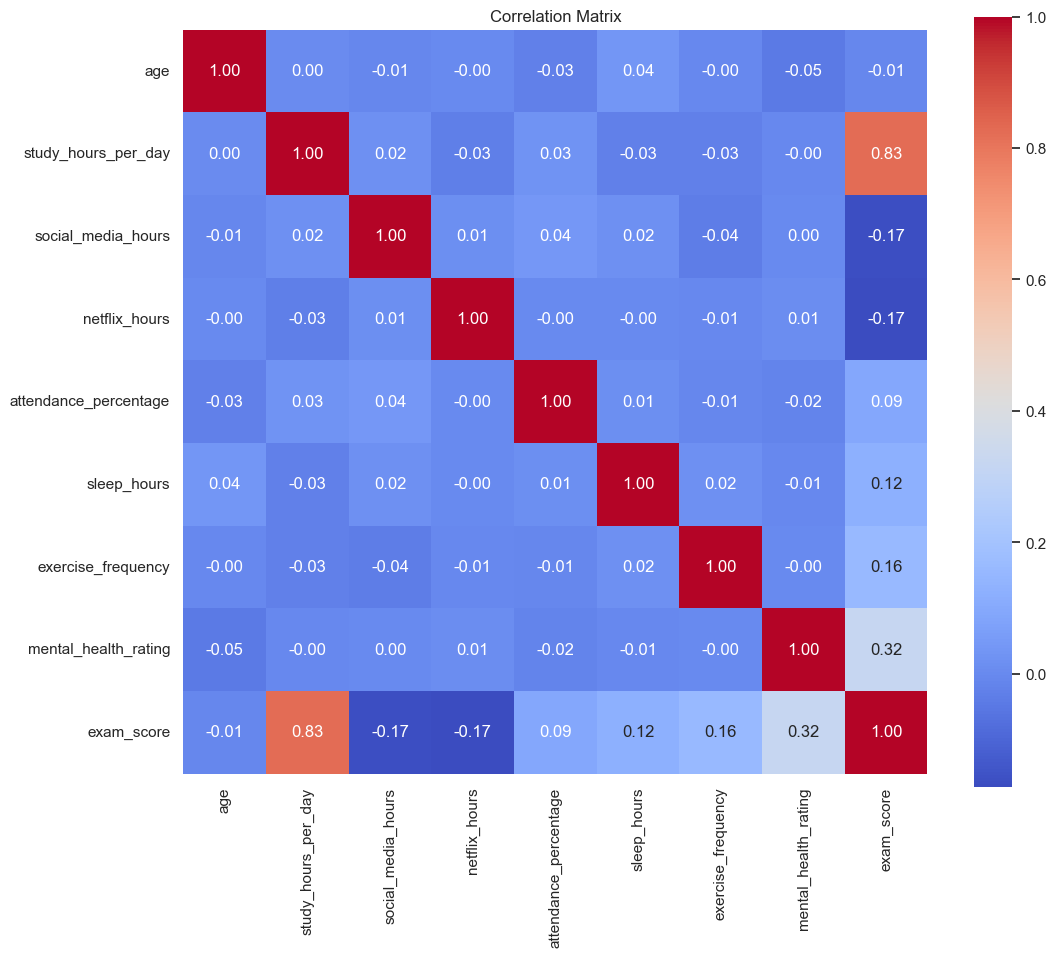

In [10]:
plt.figure(figsize=(12, 10))
correlation = df[numerical_cols].corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()


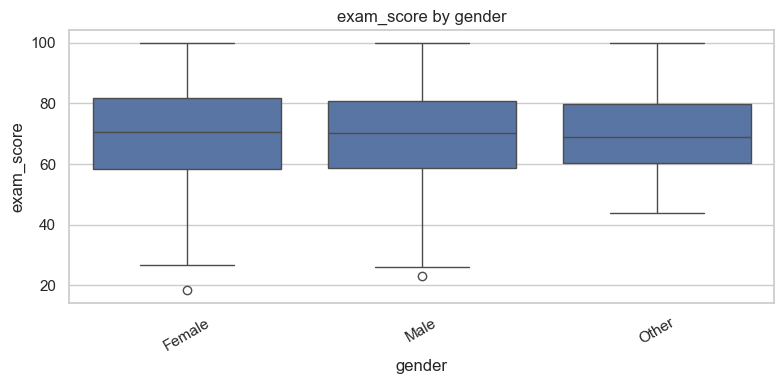

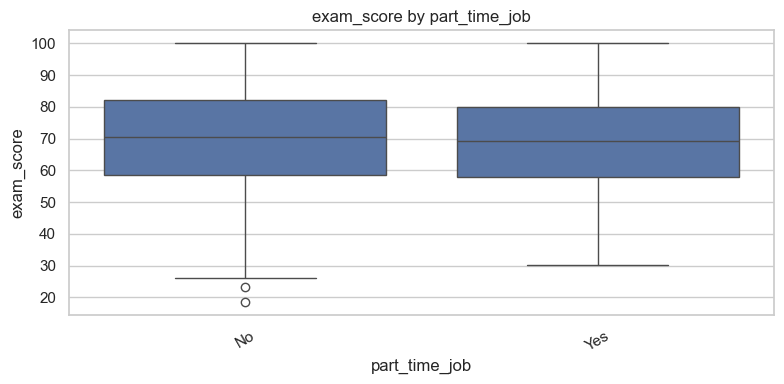

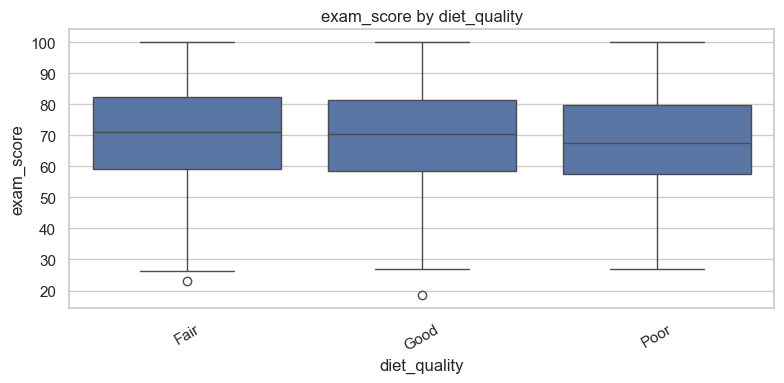

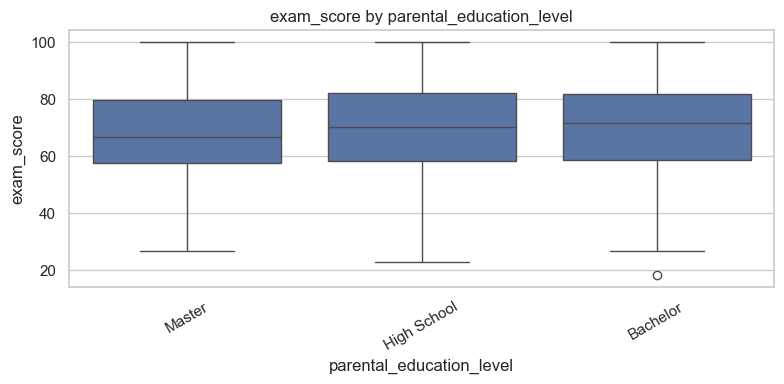

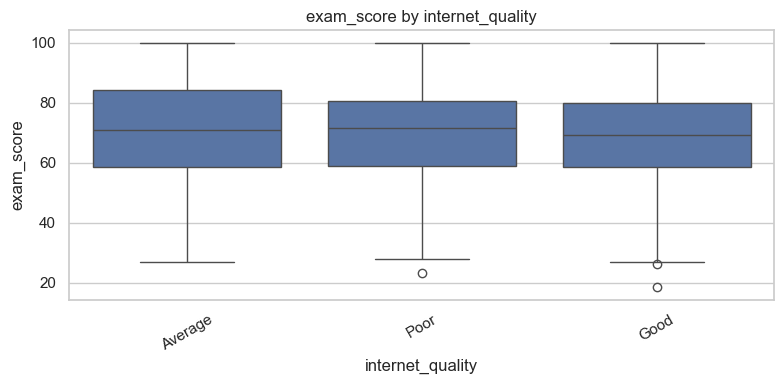

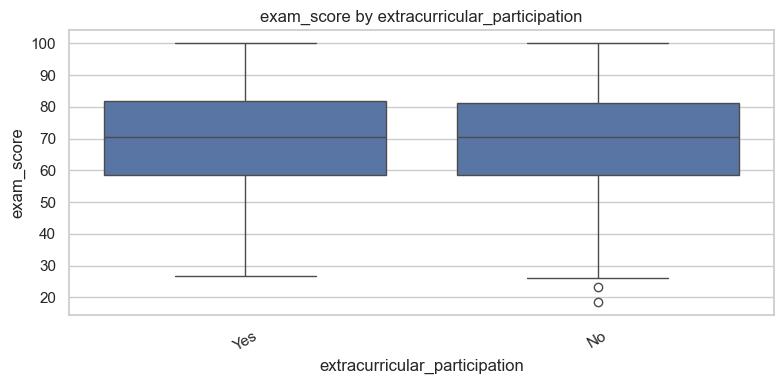

In [11]:
target = 'exam_score'

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col, y=target)
    plt.title(f'{target} by {col}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


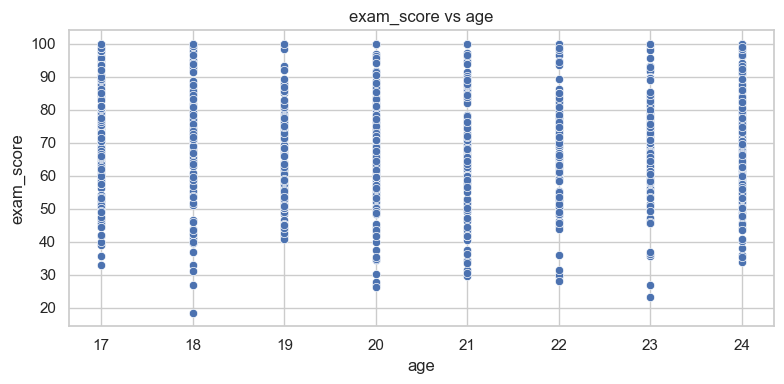

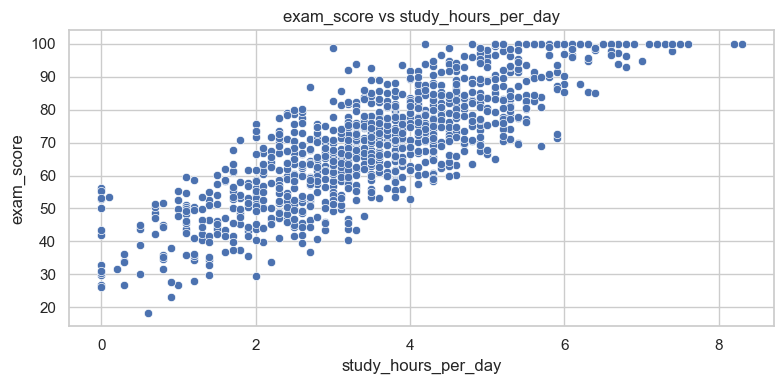

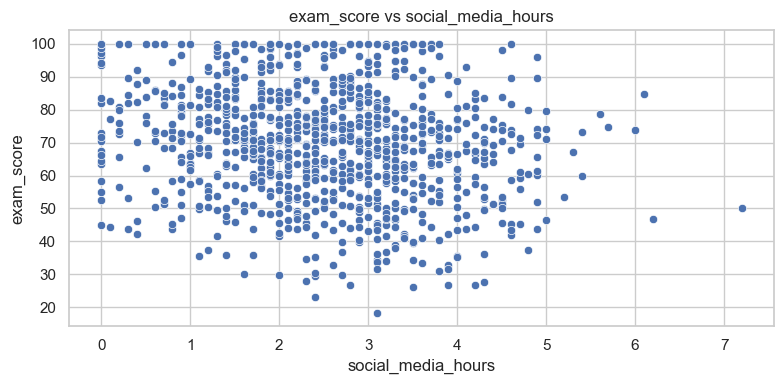

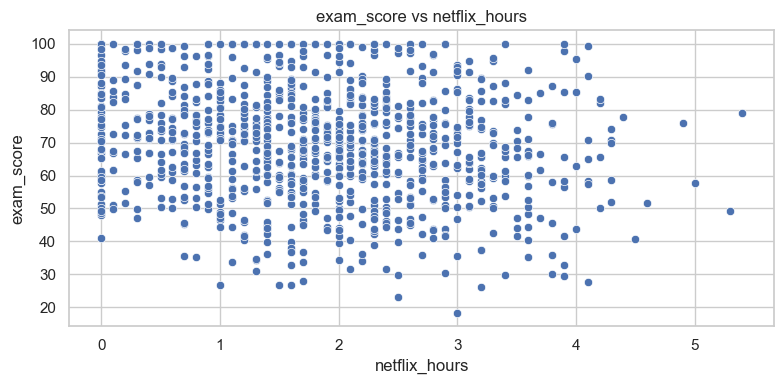

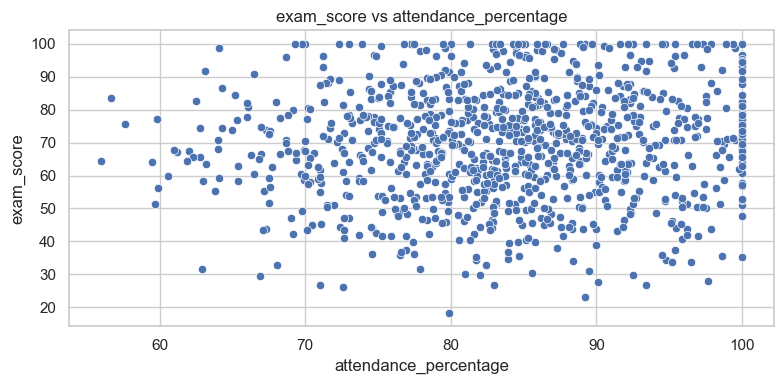

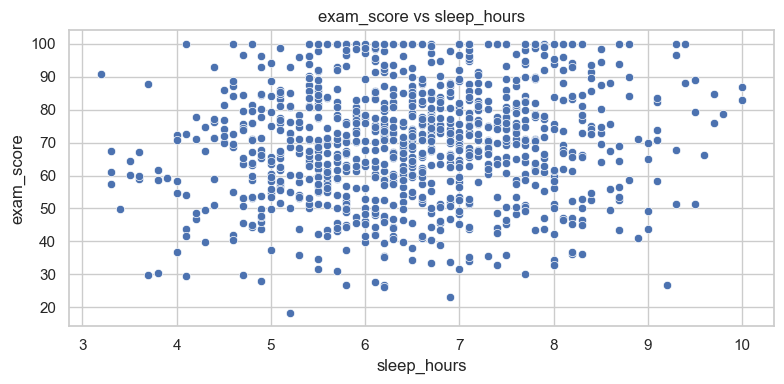

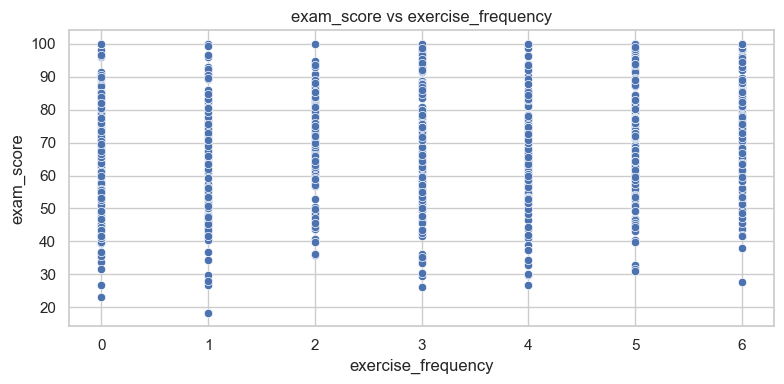

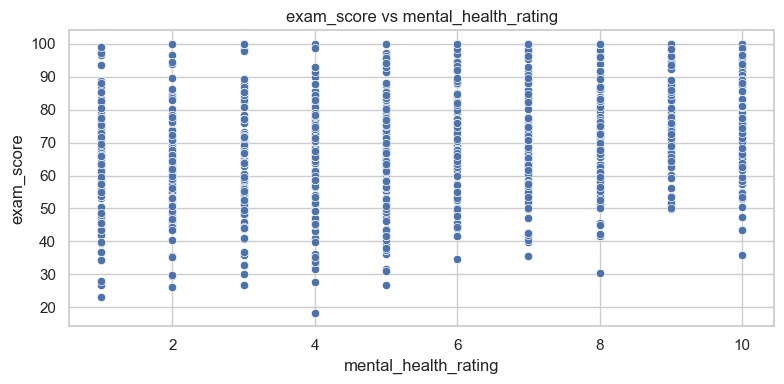

In [12]:
for col in numerical_cols:
    if col != target:
        plt.figure(figsize=(8, 4))
        sns.scatterplot(data=df, x=col, y=target)
        plt.title(f'{target} vs {col}')
        plt.tight_layout()
        plt.show()


In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_label_map = {
    1: 'High Performers',    
    2: 'Average',              
    0: 'Struggling Students'  
}

df['cluster_label'] = df['cluster'].map(cluster_label_map)

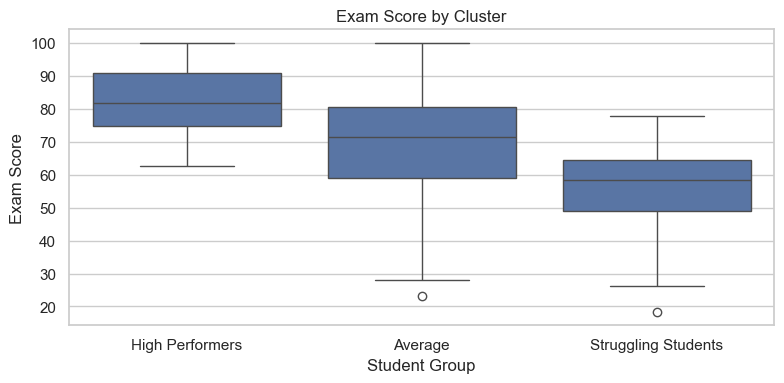

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='cluster_label', y='exam_score', order=['High Performers', 'Average', 'Struggling Students'])
plt.title('Exam Score by Cluster')
plt.xlabel('Student Group')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

In [15]:
summary = df.groupby('cluster_label').mean(numeric_only=True)
summary.T 


cluster_label,Average,High Performers,Struggling Students
age,20.629630,20.260143,20.684964
study_hours_per_day,3.461728,4.541766,2.592601
social_media_hours,2.477778,2.368735,2.652983
netflix_hours,1.729630,1.656086,2.018138
attendance_percentage,85.190123,85.787351,82.066826
sleep_hours,6.450617,6.574940,6.372792
exercise_frequency,3.166667,3.174224,2.861575
mental_health_rating,5.561728,6.312649,4.515513
exam_score,69.717284,83.043437,56.114797
cluster,2.000000,1.000000,0.000000


In [16]:
X = df_encoded.drop(columns=['exam_score'])
y = df_encoded['exam_score']



In [17]:
def logging_callback(study, frozen_trial):
    previous_best_value = study.user_attrs.get("previous_best_value", None)
    if previous_best_value != study.best_value:
        study.set_user_attr("previous_best_value", study.best_value)
        with open("magic_best_values.txt", "a") as f:
            f.write(f'{str(frozen_trial.params)} Value = {str(frozen_trial.value)}\n')

class EarlyStoppingCallback:
    def __init__(self, early_stopping_rounds: int, direction: str = "minimize") -> None:
        self.early_stopping_rounds = early_stopping_rounds
        self._iter = 0

        if direction == "minimize":
            self._operator = operator.lt
            self._score = np.inf
        elif direction == "maximize":
            self._operator = operator.gt
            self._score = -np.inf
        else:
            raise ValueError(f"Invalid direction: {direction}")

    def __call__(self, study: optuna.Study, trial: optuna.Trial) -> None:
        if self._operator(study.best_value, self._score):
            self._iter = 0
            self._score = study.best_value
        else:
            self._iter += 1

        if self._iter >= self.early_stopping_rounds:
            study.stop()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
def objective(trial):
    alpha = trial.suggest_float("alpha", 0.01, 100.0, log=True)
    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    return rmse

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
early_stopping = EarlyStoppingCallback(early_stopping_rounds=100, direction='minimize')

study.optimize(objective, n_trials=None, callbacks=[early_stopping, logging_callback])

[I 2025-05-02 15:15:10,683] A new study created in memory with name: no-name-8d3b6efa-c723-4568-9bac-3a8bc0bb11da
[I 2025-05-02 15:15:10,691] Trial 0 finished with value: 5.151361285616088 and parameters: {'alpha': 0.31489116479568624}. Best is trial 0 with value: 5.151361285616088.
[I 2025-05-02 15:15:10,697] Trial 1 finished with value: 5.337179161691373 and parameters: {'alpha': 63.512210106407046}. Best is trial 0 with value: 5.151361285616088.
[I 2025-05-02 15:15:10,702] Trial 2 finished with value: 5.163576133801814 and parameters: {'alpha': 8.471801418819979}. Best is trial 0 with value: 5.151361285616088.
[I 2025-05-02 15:15:10,709] Trial 3 finished with value: 5.1541972487500844 and parameters: {'alpha': 2.481040974867813}. Best is trial 0 with value: 5.151361285616088.
[I 2025-05-02 15:15:10,713] Trial 4 finished with value: 5.151025541292678 and parameters: {'alpha': 0.04207988669606638}. Best is trial 4 with value: 5.151025541292678.
[I 2025-05-02 15:15:10,720] Trial 5 fini

In [21]:
print("Best RMSE:", study.best_value)
print("Best Parameters:", study.best_params)

best_alpha = study.best_params['alpha']
final_model = make_pipeline(StandardScaler(), Ridge(alpha=best_alpha))
final_model.fit(X_train, y_train)

# Predict and evaluate
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)

print(f"✅ Final RMSE (Train): {rmse_train:.2f}")
print(f"✅ Final RMSE (Test):  {rmse_test:.2f}")
print("R² Score:", r2_score(y_test, y_test_pred))

Best RMSE: 5.150986380200099
Best Parameters: {'alpha': 0.01000156583333449}
✅ Final RMSE (Train): 5.34
✅ Final RMSE (Test):  5.15
R² Score: 0.8965302256924584


In [22]:
feature_names = X.columns

ridge_model = final_model.named_steps['ridge']        
scaler = final_model.named_steps['standardscaler']    

coefs = ridge_model.coef_


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    'AbsImportance': np.abs(coefs)
}).sort_values(by='AbsImportance', ascending=False)

print(importance_df.head(10))


                                 Feature  Coefficient  AbsImportance
1                    study_hours_per_day    14.144611      14.144611
7                   mental_health_rating     5.565018       5.565018
2                     social_media_hours    -3.129695       3.129695
6                     exercise_frequency     2.656636       2.656636
3                          netflix_hours    -2.531536       2.531536
5                            sleep_hours     2.421832       2.421832
4                  attendance_percentage     1.349619       1.349619
11                     diet_quality_Good    -0.463772       0.463772
13  parental_education_level_High School    -0.263862       0.263862
14       parental_education_level_Master    -0.261285       0.261285


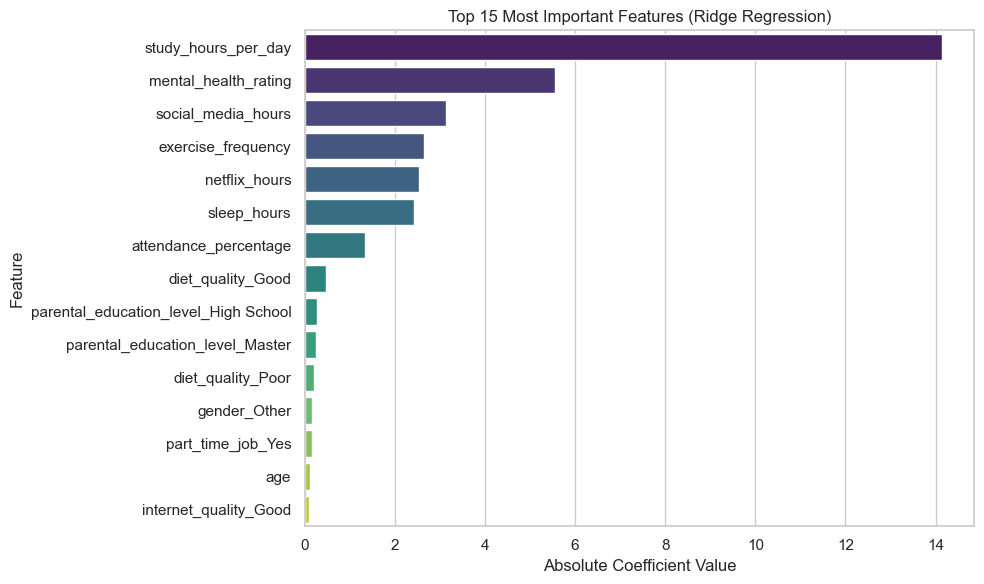

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='AbsImportance', y='Feature', palette='viridis')
plt.title("Top 15 Most Important Features (Ridge Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
